#### 1. Feedforward neural language model

The **Feedforward Neural Language Model** overcomes a key limitation of n-gram models by replacing discrete word representations with **learned dense vectors (embeddings)**. Words with similar meanings, such as *cat* and *dog*, can learn similar representations in the vector space, enabling the model to **generalize to word contexts or combinations that it has not seen exactly during training**.

![Image](images/img%2003.png)

Step 01: Input text<br>
`the cat was walking dog room`

step 02: Tokenized text<br>
`["the", "cat", "was", "walking", "dog", "room"]`

Step 03: Token IDs<br>
We have a fixed vocabulary of size $V=6$, each word assigned an integer index:
| word | id |
|---|---|
| the | 0 |
| cat | 1 |
| was | 2 |
| dog | 3 |
| walking | 4 |
| room | 5 |

step 04: Token embeddings<br>
The model has a trainable matrix (embedding matrix) $E \in \mathbb{R}^{V\times d}$, V = vocabulary size, $d=2$ columns. First randomly initialized (later learned by training):

$$E = \begin{bmatrix}
0.10 & 0.43 \\ % the (id 0)
0.21 & 0.09 \\ % cat (id 1)
-0.15 & 0.29 \\ % was (id 2)
-0.12 & 0.78 \\ % dog (id 3)
0.93 & -0.23 \\ % walking (id 4)
0.58 & 0.06 % room (id 5)
\end{bmatrix}$$

**Lookup:**<br>
$$E_{[1]} = e_{cat} = [0.21,\ 0.09] \qquad (\text{row 1, since cat's id} = 1)$$
$$E_{[2]} = e_{was} = [-0.15,\ 0.29] \qquad (\text{row 2, since was's id} = 2)$$

> This is the replacement for a discrete word / one-hot vector — instead of representing `cat` as a sparse $[0,1,0,0,0,0]$, we represent it as a dense, meaningful $[0.21, 0.09]$ that can be moved around during training.

Step 05: Concatenation<br>
$$x = [e_{cat}\,;\,e_{was}] = [0.21,\ 0.09,\ -0.15,\ 0.29] \in \mathbb{R}^4$$

Step 06: Hidden layer<br>
$$h = \tanh(W_1 x + b_1) \in \mathbb{R}^{m}$$

Step 07: Output logits<br>
One raw score per vocabulary word (6 scores):
$$s = Wh \in \mathbb{R}^{V}$$

| word | logit $s_i$ |
|---|---|
| the | 0.8 |
| cat | 1.2 |
| was | 0.3 |
| dog | 0.5 |
| walking | 2.9 |
| room | 0.4 |

Step 08: Softmax<br>
Convert logits into probabilities:
$$
P_i = \frac{e^{s_i}}{\sum_{j} e^{s_j}}
$$

| word | $e^{s_i}$ | $P_i$ |
|---|---|---|
| the | 2.226 | 0.079 |
| cat | 3.320 | 0.118 |
| was | 1.350 | 0.048 |
| dog | 1.649 | 0.058 |
| walking | 18.174 | **0.644** |
| room | 1.492 | 0.053 |

(denominator $\sum_j e^{s_j} = 28.21$; probabilities sum to $1.000$)

step 09: prediction<br>
Given `"cat was"`, `walking` has the highest probability (0.644). Therefore `cat was → walking`.

step 10: calculate loss<br>
$$L_t = -\log p_\theta(\text{walking}\mid\text{cat, was}) = -\log(0.644) \approx 0.440$$

If instead the true next word had been `dog` (probability 0.058), the loss would be *much higher*:
$$-\log(0.058) \approx 2.840$$
the model gets penalized more for putting less mass on the correct word. That's the whole training signal: gradient descent nudges $E, W_1, b_1, W$ so that $p(\text{true next word})$ goes up and the loss goes down.

#### Training the Feedforward Neural Language Model: MLE and Cross-Entropy
##### Training objective: Maximum Likelihood Estimation (MLE)
The model has learnable parameters $\theta$  including the embedding matrix $E$, the hidden layer weights $W_1, b_1$, and the output weights $W$. Training means searching for the $\theta$ that makes the training data most probable under the
model:

$$
\arg\max_\theta \sum_{x \in D_{\text{train}}} \log p_\theta(x) = \arg\max_\theta \sum_{x \in D_{\text{train}}} \sum_{t=1}^{T} \log p_\theta(x_t \mid x_{1:t-1})
$$

Where:
- $D_{\text{train}}$ = the training set (a collection of sequences $x$)
- $p_\theta(x)$ = the probability the model assigns to a whole sequence $x$
- $\arg\max_\theta$ = find the parameter values that make this sum as large as possible
- Outer sum: loop over every training sequence
- Inner sum: loop over every position $t$ in that sequence
- $p_\theta(x_t \mid x_{1:t-1})$: the softmax output

> **Note on notation:** the feedforward LM doesn't actually condition on the full
> history $x_{1:t-1}$. it uses a fixed window of the last $k = n-1$ words (
> in the example above used $k=2$: `cat, was`). So from here on, $x_{1:t-1}$ is
> replaced with $x_{t-k:t-1}$ to reflect this truncated context.

##### Cross-Entropy Loss(per-token loss)

Maximizing the log-probability is equivalent to minimizing its negative. Therefore, the per-token negative log-likelihood, which corresponds to cross-entropy for a one-hot target, is:

$$
L_t = -\log p_\theta(x_t \mid x_{t-k:t-1})
$$

The loss is small when the model assigns a high probability to the correct next token and large when it assigns a low probability.

##### General Cross-Entropy Loss

$$
L_{CE} = -\sum_{i=1}^{\text{num classes}} y_i \log(p_i)
$$

where $y_i$ is the true one-hot encoded label and $p_i$ is the predicted probability distribution across number of classes.

##### Total Training Objective

The total training objective can therefore be written as:

$$
\arg\max_\theta \sum_{x \in D_{\text{train}}} \sum_{t} \log p_\theta(x_t \mid x_{t-k:t-1}) = \arg\min_{\theta} \sum_{x \in \mathcal{D}_{\text{train}}} \sum_{t} -\log p_\theta(x_t \mid x_{t-k:t-1})
$$

#### Data preprocessing

In [1]:
######################################################################
#     Read multiple books and build a combined character vocabulary
######################################################################

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


book_files = [
    'The Mysterious Island.txt',
    'The Modern Prometheus.txt',
    'The Whale.txt',
    'The Adventures of Sherlock Holmes.txt',
    'Pride and Prejudice.txt',
    'Alice\'s Adventures in Wonderland.txt'
]

# Separator inserted between books so the model can (mostly) tell where one book ends and the next begins.
SEPARATOR = "\n\n<|endofbook|>\n\n"

raw_texts = []
for path in book_files:
    with open(path, 'r', encoding='utf-8') as f:
        book_text = f.read()
    raw_texts.append(book_text)
    print(f"{path}: {len(book_text):,} characters")

text = SEPARATOR.join(raw_texts)
print(f"\nTotal characters across {len(book_files)} books: {len(text):,}")



chars = sorted(set(text))                                # sorted list of unique characters across ALL books
print("Unique characters:", chars[:20])

char2idx = {ch: i for i, ch in enumerate(chars)}          # character -> integer index
print("Character to index mapping:", char2idx)

idx2char = {i: ch for ch, i in char2idx.items()}          # integer index -> character
print("Index to character mapping:", idx2char)

V = len(chars)                                            # total vocabulary size (may be larger than single-book version)
print("Vocabulary size(unique chars):", V)

print(f"First 100 chars: {text[:100]!r}")                 # sanity check: should show the start of book 1

text_ids = torch.tensor([char2idx[ch] for ch in text], dtype=torch.long)   # encode entire combined text
print("Text Indexes:", text_ids)

The Mysterious Island.txt: 1,112,362 characters
The Modern Prometheus.txt: 438,841 characters
The Whale.txt: 1,238,279 characters
The Adventures of Sherlock Holmes.txt: 581,601 characters
Pride and Prejudice.txt: 748,167 characters
Alice's Adventures in Wonderland.txt: 163,950 characters

Total characters across 6 books: 4,283,285
Unique characters: ['\n', ' ', '!', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3']
Character to index mapping: {'\n': 0, ' ': 1, '!': 2, '#': 3, '$': 4, '%': 5, '&': 6, "'": 7, '(': 8, ')': 9, '*': 10, '+': 11, ',': 12, '-': 13, '.': 14, '/': 15, '0': 16, '1': 17, '2': 18, '3': 19, '4': 20, '5': 21, '6': 22, '7': 23, '8': 24, '9': 25, ':': 26, ';': 27, '<': 28, '=': 29, '>': 30, '?': 31, 'A': 32, 'B': 33, 'C': 34, 'D': 35, 'E': 36, 'F': 37, 'G': 38, 'H': 39, 'I': 40, 'J': 41, 'K': 42, 'L': 43, 'M': 44, 'N': 45, 'O': 46, 'P': 47, 'Q': 48, 'R': 49, 'S': 50, 'T': 51, 'U': 52, 'V': 53, 'W': 54, 'X': 55, 'Y': 56, 'Z': 57, '[':

In [2]:
#####################################
# For One Book
#####################################

#import torch
#import torch.nn as nn
#import torch.nn.functional as F
#import torch.optim as optim
#from torch.utils.data import Dataset, DataLoader

# read the text file and build vocabulary
#text = open('The Mysterious Island.txt', 'r', encoding='utf-8').read()
#print(f"Total characters: {len(text):,}")
#print("Title of The Book:", text[52:72])

#start_indx = text.find('THE MYSTERIOUS ISLAND')
#end_indx = text.find('End of the Project Gutenberg')
#print(start_indx, end_indx)

#text = text[start_indx:end_indx]
#char_set = set(text)
#print('Total Length:', len(text))
#print('Unique Characters:', len(char_set))


#chars = sorted(set(text))                                 # create a sorted list of unique characters in the text
#print("Unique characters:", chars[:20])

#char2idx = {ch: i for i, ch in enumerate(chars)}          # create a dictionary mapping each character to a unique integer index
#print("Character to index mapping:", char2idx)

#idx2char = {i: ch for ch, i in char2idx.items()}          # create a dictionary mapping each integer index back to its corresponding character
#print("Index to character mapping:", idx2char)

#V = len(chars)                                            # get the total number of unique characters in the text(vocabulary size)
#print("Vocabulary size(unique chars):", V)

#print(f"First 100 chars: {text[:100]!r}")                 # print the first 100 characters of the text for reference

#text_ids = torch.tensor([char2idx[ch] for ch in text], dtype=torch.long)    # convert/Encode the entire text into a tensor of character integer indices
#print("Text Indexes:", text_ids)

In [3]:
# ---------------------------------------------------------------------------------------------------------------------------------
# Train/validation/test split on the ID tensor (before windowing) 80% train / 10% val / 10% test, taken in order (no shuffling of
# raw text — shuffling happens later, at the DataLoader level, and only within each split so windows never cross split boundaries)
# ---------------------------------------------------------------------------------------------------------------------------------

Context_size = 40
Train_ratio = 0.8
Val_ratio = 0.1
# remaining 0.1 goes to test

n = len(text_ids)                                  # get the total number of characters in the text
train_end = int(Train_ratio * n)                   # calculate the index where the training split ends (80% of the total characters)
val_end = int((Train_ratio + Val_ratio) * n)       # calculate the index where the validation split ends (90% of the total characters)

train_ids = text_ids[:train_end]                   # get the training character indices (first 80% of the text)
val_ids = text_ids[train_end:val_end]              # get the validation character indices (next 10% of the text)
test_ids = text_ids[val_end:]                      # get the test character indices (remaining 10% of the text)

print("Train chars:", len(train_ids))
print("Val chars:", len(val_ids))
print("Test chars:", len(test_ids))

Train chars: 3426628
Val chars: 428328
Test chars: 428329


In [4]:
######################################################################################################################
# Dataset class that takes a tensor of character indices and a context size, and returns pairs of (context, target) 
# where context is a fixed-length window of characters and target is the next character in the sequence.
######################################################################################################################

class CharContextDataset(Dataset):
    def __init__(self, ids: torch.Tensor, context_size: int):
        self.ids = ids
        self.context_size = context_size

    def __len__(self):
        return len(self.ids) - self.context_size  # last valid start index

    def __getitem__(self, i):
        context = self.ids[i: i + self.context_size]   # (context_size,)
        target = self.ids[i + self.context_size]        # scalar: next char id
        return context, target

train_dataset = CharContextDataset(train_ids, Context_size)
val_dataset = CharContextDataset(val_ids, Context_size)
test_dataset = CharContextDataset(test_ids, Context_size)

In [5]:
####################################################################
#                        DataLoaders
####################################################################
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,     # even-sized batches for training
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # no need to shuffle validation
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # never shuffle test either
    drop_last=False,
    num_workers=0,
)

print(f"Training examples: {len(train_dataset):,}  |  batches/epoch: {len(train_loader):,}")
print(f"Validation examples: {len(val_dataset):,}  |  batches/epoch: {len(val_loader):,}")
print(f"Test examples: {len(test_dataset):,}  |  batches/epoch: {len(test_loader):,}")

Training examples: 3,426,588  |  batches/epoch: 13,385
Validation examples: 428,288  |  batches/epoch: 1,673
Test examples: 428,289  |  batches/epoch: 1,674


In [6]:
#################################################################
#      Sanity check: pull one batch and confirm shapes
#################################################################

xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)   # (BATCH_SIZE, Context_size)
print("Batch y shape:", yb.shape)   # (BATCH_SIZE,)

Batch X shape: torch.Size([256, 40])
Batch y shape: torch.Size([256])


#### Define the Model

In [7]:
class FeedforwardLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, Context_size):
        super(FeedforwardLM, self).__init__()
        self.embed  = nn.Embedding(vocab_size, embed_dim)                    # E: (V: vocab_size, d: embed_dim) learnable lookup table
        self.hidden = nn.Linear(Context_size * embed_dim, hidden_dim)        # W1, b1
        self.out    = nn.Linear(hidden_dim, vocab_size)                      # W (+ bias): one score per vocab word

    def forward(self, context_idx):
         # context_idx: (batch, context_size) word ids
        e = self.embed(context_idx)          # (batch_size, context_size, embed_dim))
        x = e.view(e.size(0), -1)            # flatten to (batch_size, context_size * embed_dim)
        h = torch.tanh(self.hidden(x))       # (batch_size, hidden_size)
        s = self.out(h)                      # batch_size, vocab_size)  # raw scores (logits) for each word in the vocabulary #we can also use log softmax here, F.log_softmax(s,dim=1)
        return s   

#### Define Model and associated Parameters

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Hyperparameters
embed_dim = 32
hidden_dim = 256
Context_size = 40
learning_rate = 0.001
num_epochs = 80
grad_clip = 1.0

model = FeedforwardLM(vocab_size=V, embed_dim=embed_dim, hidden_dim=hidden_dim, Context_size=Context_size).to(device)
print(model)
print(f"Total TrainableModel parameters: {sum(p.numel() for p in model.parameters())}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
print("Loss function:", criterion)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
print("Optimizer:", optimizer)

# Learning rate scheduler (Cosine Annealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
print("Scheduler:", scheduler)

Using device: cpu
FeedforwardLM(
  (embed): Embedding(120, 32)
  (hidden): Linear(in_features=1280, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=120, bias=True)
)
Total TrainableModel parameters: 362616
Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x000001EEDD8E9590>


#### Training and Validation

In [9]:
######################################################################
#                    Training function
######################################################################

def train_one_epoch(model, data_loader, criterion, optimizer, device, grad_clip=None):
    model.train()

    total_loss = 0.0
    total_count = 0
    total_correct = 0

    for xb, yb in data_loader:
        # Move data to the appropriate device (GPU or CPU)
        xb = xb.to(device, non_blocking=True)  # (batch_size, context_size)
        yb = yb.to(device, non_blocking=True)  #(batch_size,)

        # Clear Previous Gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward Pass
        logits = model(xb)  # (batch_size, vocab_size)

        # Calculate Loss
        loss = criterion(logits, yb)

        # Backward Pass(Backpropagation)
        loss.backward()

        # Gradient Clipping (if specified) / scale the gradients to prevent exploding gradients
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # Update Model Parameters
        optimizer.step()

        # update metrics
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == yb).sum().item()

    epoch_loss = total_loss / total_count
    epoch_accuracy = total_correct / total_count
    return epoch_loss, epoch_accuracy


#######################################################################
#                    Validation function
#######################################################################
@torch.no_grad() #  decorator disables gradient calculation, which reduces memory consumption and speeds up computations during validation since we don't need to compute gradients for backpropagation.
def validate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_count = 0
    total_correct = 0

    for xb, yb in data_loader:
        # Move data to the appropriate device (GPU or CPU)
        xb = xb.to(device, non_blocking=True)  # (batch_size, context_size)
        yb = yb.to(device, non_blocking=True)  #(batch_size,)

        # Forward Pass
        logits = model(xb)  # (batch_size, vocab_size)

        # Calculate Loss
        loss = criterion(logits, yb)

        # update metrics
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == yb).sum().item()

    epoch_loss = total_loss / total_count
    epoch_accuracy = total_correct / total_count
    return epoch_loss, epoch_accuracy

#### Experiments

In [10]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []
best_val_loss = float('inf')
best_model_state = None

# early stopping config
patience = 5          # how many epochs to wait for improvement before stopping
patience_counter = 0
min_delta = 1e-4      # ignore improvements smaller than this (noise)

for epoch in range(1, num_epochs + 1):
    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device, grad_clip=grad_clip)
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)

    # Store/save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    # step the scheduler once per epoch (after optimizer.step() calls inside train_one_epoch)
    scheduler.step()

    # Check for best validation loss
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0                     # reset patience on real improvement
    else:
        patience_counter += 1                    # no meaningful improvement this epoch

    # print progress for the current epoch
    print(f"Epoch [{epoch}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping if no improvement for 'patience' epochs
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs).")
        break

    # restore best weights(model) after training ends (whether early stopping or after all epochs)
model.load_state_dict(best_model_state)
print("Restored best model weights from epoch with lowest validation loss.")

Epoch [1/80] | Train Loss: 1.8773, Train Acc: 0.4531 | Val Loss: 1.7617, Val Acc: 0.4779 | LR: 0.001000
Epoch [2/80] | Train Loss: 1.6718, Train Acc: 0.5045 | Val Loss: 1.6912, Val Acc: 0.4988 | LR: 0.000998
Epoch [3/80] | Train Loss: 1.6149, Train Acc: 0.5197 | Val Loss: 1.6523, Val Acc: 0.5114 | LR: 0.000997
Epoch [4/80] | Train Loss: 1.5817, Train Acc: 0.5282 | Val Loss: 1.6350, Val Acc: 0.5148 | LR: 0.000994
Epoch [5/80] | Train Loss: 1.5588, Train Acc: 0.5344 | Val Loss: 1.6145, Val Acc: 0.5192 | LR: 0.000990
Epoch [6/80] | Train Loss: 1.5414, Train Acc: 0.5395 | Val Loss: 1.6136, Val Acc: 0.5213 | LR: 0.000986
Epoch [7/80] | Train Loss: 1.5279, Train Acc: 0.5431 | Val Loss: 1.6004, Val Acc: 0.5223 | LR: 0.000981
Epoch [8/80] | Train Loss: 1.5165, Train Acc: 0.5459 | Val Loss: 1.6012, Val Acc: 0.5256 | LR: 0.000976
Epoch [9/80] | Train Loss: 1.5069, Train Acc: 0.5484 | Val Loss: 1.5881, Val Acc: 0.5277 | LR: 0.000969
Epoch [10/80] | Train Loss: 1.4984, Train Acc: 0.5507 | Val Loss

In [11]:
##############################################################
#           Test set evaluation (perplexity)
##############################################################
import math

test_loss, test_accuracy = validate(model, test_loader, criterion, device)
test_perplexity = math.exp(test_loss)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f} | Test Perplexity: {test_perplexity:.2f}")

Test Loss: 1.5829 | Test Accuracy: 0.5408 | Test Perplexity: 4.87


In [13]:
######################################################################
#         Save model checkpoint + vocabulary (reproducibility)
######################################################################

checkpoint = {
    "model_state_dict": model.state_dict(),
    "char2idx": char2idx,
    "idx2char": idx2char,
    "config": {
        "vocab_size": V,
        "embed_dim": embed_dim,
        "hidden_dim": hidden_dim,
        "context_size": Context_size,
    },
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "test_perplexity": test_perplexity,
}

torch.save(checkpoint, "feedforwardlm_final.pt")
print("Model + vocab saved to feedforwardlm_final.pt")

Model + vocab saved to feedforwardlm_final.pt


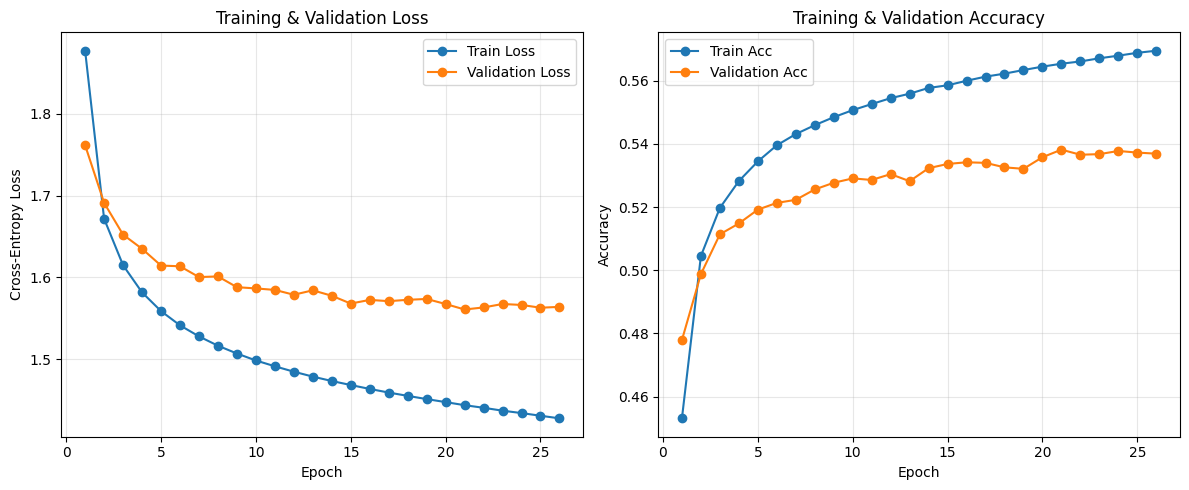

In [14]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Acc', marker='o')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feedforwardlm_curves.png', dpi=150)  # useful if you're pulling this into a paper/report later
plt.show()

In [15]:
######################################################################
#                    Text Generation Function
######################################################################

@torch.no_grad()
def generate_text(model, seed_text: str, char2idx: dict, idx2char: dict, context_size: int, length: int = 300, temperature: float = 0.8, top_k: int = None, device: torch.device = device,):
    """
    Generate text autoregressively from a feedforward LM.
    
    seed_text   : starting string, MUST be >= context_size characters
                  (the model only ever sees a fixed-size window, so it
                  needs a full window to make its first prediction)

    num_chars   : how many new characters to generate

    temperature : >1.0 = more random/diverse, <1.0 = more conservative/greedy,
                  1.0 = sample directly from the model's distribution

    top_k       : if set, restrict sampling to the k most likely next
                  characters at each step (filters out low-probability noise)
    """
    model.eval()

    # Unknown-character safety: fall back to a known char (e.g. space) if seed
    # contains anything outside the training vocabulary.
    unk_fallback = char2idx.get(' ', 0)
    ids = [char2idx.get(ch, unk_fallback) for ch in seed_text]

    # Left-pad with spaces if the seed is shorter than context_size
    if len(ids) < context_size:
        ids = [unk_fallback] * (context_size - len(ids)) + ids
    else:
        ids = ids[-context_size:]   # keep only the most recent context_size chars

    context = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, context_size)
    generated_chars = [idx2char[i] for i in ids]   # decode ids -> characters
    
    for _ in range(length):
        logits = model(context)                      # (1, vocab_size)
        logits = logits / max(temperature, 1e-8)      # temperature scaling

        if top_k is not None:
            top_vals, top_idx = torch.topk(logits, top_k, dim=-1)
            filtered_logits = torch.full_like(logits, float('-inf'))
            filtered_logits.scatter_(1, top_idx, top_vals)
            logits = filtered_logits

        probs = F.softmax(logits, dim=-1)             # (1, vocab_size)
        next_id = torch.multinomial(probs, num_samples=1).item()

        generated_chars.append(idx2char[next_id])

        # slide the context window forward by one character
        next_id_tensor = torch.tensor([[next_id]], device=device)
        context = torch.cat([context[:, 1:], next_id_tensor], dim=1)

    return ''.join(generated_chars)

In [16]:
######################################################################
#              Generate samples at different settings
######################################################################

seed = "the island was covered with"

print("=== Temperature 0.5 (conservative) ===")
print(generate_text(model, seed, char2idx, idx2char, Context_size, length=300, temperature=0.5))

print("\n=== Temperature 0.8, top_k=10 (balanced) ===")
print(generate_text(model, seed, char2idx, idx2char, Context_size, length=300, temperature=0.8, top_k=10))

print("\n=== Temperature 1.2 (more random) ===")
print(generate_text(model, seed, char2idx, idx2char, Context_size, length=300, temperature=1.2))

=== Temperature 0.5 (conservative) ===
             the island was covered with the sun the sea through the left the sea. The words and the beloved
the east before and with a store on safe turther still to see in the extreme of the world devil
with the work and the ledge storm of the morning to the which she had been along and in her the corral stretch would to the cordly befo

=== Temperature 0.8, top_k=10 (balanced) ===
             the island was covered with the snow and fact it to do hermer conty of the marked by the most right, it is the mystery
where showsers, for and all those indeed, which my boy work
barger. Steeling had fire old arrively and servest
person with this her hand of the waters to things his downed infeed the
cellections which hand of

=== Temperature 1.2 (more random) ===
             the island was covered with itsen
by up asitant to return tabned himself day! awoets this
won—the Intant red Cyrus Harding, speen at thinks to?’ A  rasted eyouring
caterim, thy fell

![Image](images/img%2004.png)

The feedforward character-level LM learns local statistical patterns (**common words, letter sequences, suffixes**) but lacks any mechanism for modeling dependencies beyond its fixed context window, resulting in locally plausible but globally incoherent text. Lower temperatures increase fluency at the cost of diversity/repetition; higher temperatures increase novelty at the cost of well-formedness. This motivates recurrent or attention-based architectures (RNN/LSTM/Transformer) as natural extensions for improving long-range coherence.


![Image](images/img%2005.png)

#### ⚠️ Key Limitation of N-gram and feedforward neural language models

N-gram and feedforward neural language models use a **fixed/short length context window**.
They predict the next token using only a limited number of previous tokens, so they cannot directly capture dependencies from much earlier in the sequence.

## Sequence model

A sequence model is a neural network designed to process sequential data(text, speech, time series etc.) where the order of elements matters. 

![Image](images/img%2006.png)

**Parallelizable** means the model can process multiple positions in the input sequence at the same time, making it highly efficient on modern GPUs. **RNNs cannot fully do** this because each step depends on the previous one, while **CNNs and Transformers can process input sequence positions in parallel (especially during training)**.

![Image](images/img%2007.png)

#### Recurrent neural networks(RNNs)

* The limitation of **fixed/few context length** motivates sequential models such as RNNs, LSTMs, and GRUs, which can process sequences of arbitrary length but may struggle to retain information over very long distances, and later Transformers, which use a fixed maximum context length (e.g., 8K, 128K, 1M tokens, depending on the model) to capture contextual information.


* RNNs/LSTMs/GRUs can handle **longer contexts**, but they may struggle to capture **long-range dependencies** effectively due to issues such as the **vanishing/exploding gradient** problem and the difficulty of retaining information over many time steps. This motivates **attention**, which allows the model to directly focus on relevant tokens, even when they are far apart.

Example:

"The **cat**, which I adopted several years ago when I was living in a small village, is sitting on the table because **it** is hungry."

Here, **"it"** refers to **"cat."** Because the relevant words "it" and "cat" are far apart, this is an example of a **long-range dependency**.

- Long context means that a model can use information from farther back in the sequence.

---
- Repeated multiplication by weight transformations with magnitude smaller than 1 → gradients shrink → vanishing gradients.
- nRepeated multiplication by weight transformations with magnitude greater than 1 → gradients grow → exploding gradients.


![Image](images/img%2008.png)

RNNs do not need **positional embeddings**. Because an RNN processes words one by one in order (sequentially), it inherently knows the position of the word by the time step it arrives. You don't need to add a "position 1, 2, 3" vector to the token.

![Image](images/img%2009.png)

### Sequence Classification

#### Step 1: RNN hidden state update

$$ h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h) $$

Applied for $t = 1, \dots, T$. Keep only the last one, $h_T$.

#### Step 2: Logits (raw scores) via weight matrix $W$

$$ z = W h_T \quad \text{(gives } z_1, z_2, z_3 \text{ — one score per class)} $$

#### Step 3: Softmax (scores $\to$ probabilities)

$$ p_i = \frac{e^{z_i}}{\sum_{j=1}^C e^{z_j}} \quad \text{so that } p_1 + p_2 + p_3 = 1 $$

#### Step 4: Cross-Entropy Loss

$$ \mathcal{L} = - \sum_{i=1}^C y_i \log(p_i) $$

Expanded for $C = 3$:

$$ \mathcal{L} = -(y_1 \log p_1 + y_2 \log p_2 + y_3 \log p_3) $$

Let, Classes: $[Positive,Negative,Neutral]$ With one-hot $y = [y_1, y_2, y_3]$, e.g. true label = Negative:

$$ y = [0, 1, 0] \implies \mathcal{L} = -(0 \cdot \log p_1 + 1 \cdot \log p_2 + 0 \cdot \log p_3) = -\log p_2 $$


#### Main Equation

$$ \mathcal{L} = - \sum_{i=1}^C y_i \log \left( \frac{e^{(W h_T)_i}}{\sum_{j=1}^C e^{(W h_T)_j}} \right) $$

![Image](images/img%2010.png)

![Image](images/img%2011.png)

$$Total\ Loss\ \mathcal{L}(\theta) = -\frac{1}{N} \sum_{x \in D_{\text{train}}} \sum_{t} \log p_{\theta}(x_t \mid x_{<t})$$

**Where:**
- $N$ = total number of tokens predicted (across all sequences)
- $x$ = every sequence in the training dataset
- $t$ = each token position in the sequence
- $D_{\text{train}}$ = training dataset
- $x_t$ = the token at position $t$
- $x_{<t}$ = all tokens before position $t$ (the context)
- $p_{\theta}(x_t \mid x_{<t})$ = probability of token $x_t$ given previous tokens, parameterized by $\theta$

#### Cons of RNN Language Model

1. RNN training is **difficult to parallelize** across sequence positions because each hidden state depends on the previous hidden state.

2. **Autoregressive generation is slow** because each new token must be generated sequentially before the next token can be predicted.

3. RNNs struggle to learn **long-range dependencies** because gradients can vanish or explode as they are propagated across many time steps during Backpropagation Through Time (BPTT).


#### Pros of RNN Language Model

1. RNNs are naturally suited for sequential data because they maintain information from previous tokens through the hidden state.

2. RNNs can process sequences of different lengths without requiring a fixed sequence length. This is called **handling variable-length input sequences**.

3. RNNs use shared parameters across time steps. The same weight matrices $(W_{hh})$ and $(W_{xh})$ are applied at every time step, reducing the number of model parameters and making RNNs parameter-efficient.

4. RNNs are suitable for streaming or online applications where data arrives sequentially because they can process incoming data incrementally without needing the entire sequence at once.

5. RNNs are suitable for streaming or online applications where data arrives sequentially because they can process incoming data incrementally, using the previous hidden state rather than requiring the entire sequence at once.

#### Data preprocessing

In [1]:
######################################################################
#     Read multiple books and build a combined character vocabulary
######################################################################

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math


book_files = [
    'The Mysterious Island.txt',
    'The Modern Prometheus.txt',
    'The Whale.txt',
    'The Adventures of Sherlock Holmes.txt',
    'Pride and Prejudice.txt',
    'Alice\'s Adventures in Wonderland.txt'
]

# Separator inserted between books so the model can (mostly) tell where one book ends and the next begins.
SEPARATOR = "\n\n<|endofbook|>\n\n"


def clean_book(raw_text):
    start_markers = ['*** START OF', '***START OF']
    end_markers   = ['*** END OF', '***END OF']

    start = 0
    for marker in start_markers:
        idx = raw_text.find(marker)
        if idx != -1:
            newline_pos = raw_text.find('\n', idx)
            if newline_pos != -1:
                start = newline_pos + 1
            break

    end = len(raw_text)
    for marker in end_markers:
        idx = raw_text.find(marker)
        if idx != -1:
            end = idx
            break

    return raw_text[start:end].strip()

raw_texts = []
for path in book_files:
    with open(path, 'r', encoding='utf-8') as f:
        book_text = clean_book(f.read())
    raw_texts.append(book_text)
    print(f"{path}: {len(book_text):,} characters (after cleaning)")

text = SEPARATOR.join(raw_texts)
print(f"\nTotal characters across {len(book_files)} books: {len(text):,}")



chars = sorted(set(text))                                 # sorted list of unique characters across ALL books
print("Unique characters:", chars[:20])

char2idx = {ch: i for i, ch in enumerate(chars)}          # character -> integer index
print("Character to index mapping:", char2idx)

idx2char = {i: ch for ch, i in char2idx.items()}          # integer index -> character
print("Index to character mapping:", idx2char)

V = len(chars)                                            # total vocabulary size (may be larger than single-book version)
print("Vocabulary size(unique chars):", V)

print(f"First 100 chars: {text[:100]!r}")                 # sanity check: should show the start of book 1

text_ids = torch.tensor([char2idx[ch] for ch in text], dtype=torch.long)   # encode entire combined text
print("Text Indexes:", text_ids)

The Mysterious Island.txt: 1,112,261 characters (after cleaning)
The Modern Prometheus.txt: 419,336 characters (after cleaning)
The Whale.txt: 1,218,938 characters (after cleaning)
The Adventures of Sherlock Holmes.txt: 562,202 characters (after cleaning)
Pride and Prejudice.txt: 728,713 characters (after cleaning)
Alice's Adventures in Wonderland.txt: 144,599 characters (after cleaning)

Total characters across 6 books: 4,186,134
Unique characters: ['\n', ' ', '!', '$', '&', '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7']
Character to index mapping: {'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, '(': 5, ')': 6, '*': 7, ',': 8, '-': 9, '.': 10, '/': 11, '0': 12, '1': 13, '2': 14, '3': 15, '4': 16, '5': 17, '6': 18, '7': 19, '8': 20, '9': 21, ':': 22, ';': 23, '<': 24, '=': 25, '>': 26, '?': 27, 'A': 28, 'B': 29, 'C': 30, 'D': 31, 'E': 32, 'F': 33, 'G': 34, 'H': 35, 'I': 36, 'J': 37, 'K': 38, 'L': 39, 'M': 40, 'N': 41, 'O': 42, 'P': 43, 'Q': 44, 'R': 45, 'S': 46, '

In [2]:
# ##################################################################################################
# Train/validation/test split — done PER BOOK (80/10/10 each) so every split contains
# proportional representation from all 6 books, not just a slice of the concatenated corpus.
# Vocabulary reuses the global char2idx already built from the full combined `text`.
# ##################################################################################################

Sequence_Length = 100       # <-- RNN sequence length (replaces the feedforward Context_size)
Train_ratio = 0.8
Val_ratio = 0.1
# remaining 0.1 goes to test

train_parts, val_parts, test_parts = [], [], []

for book_text in raw_texts:
    n = len(book_text)
    train_end = int(Train_ratio * n)
    val_end   = int((Train_ratio + Val_ratio) * n)

    train_parts.append(book_text[:train_end])
    val_parts.append(book_text[train_end:val_end])
    test_parts.append(book_text[val_end:])

train_text = SEPARATOR.join(train_parts)
val_text   = SEPARATOR.join(val_parts)
test_text  = SEPARATOR.join(test_parts)

# Reuse the global char2idx (built earlier from the full combined `text`) — no vocab rebuild here.
train_ids = torch.tensor([char2idx[ch] for ch in train_text], dtype=torch.long)
val_ids   = torch.tensor([char2idx[ch] for ch in val_text],   dtype=torch.long)
test_ids  = torch.tensor([char2idx[ch] for ch in test_text],  dtype=torch.long)

print("Train chars:", len(train_ids))
print("Val chars:", len(val_ids))
print("Test chars:", len(test_ids))

Train chars: 3348921
Val chars: 418690
Test chars: 418693


## Dataset Class

Unlike the feedforward `CharContextDataset` which returned `(context, next_char)`,
the RNN dataset returns **two sequences of equal length**: the input sequence and the
target sequence shifted by one position. This way the model produces a prediction at
**every** time step, and the loss is averaged over all of them.

| Feedforward dataset | RNN dataset |
|---------------------|-------------|
| `x = ids[i : i+context_size]` | `x = ids[start : start+seq_len]` |
| `y = ids[i + context_size]` (single char) | `y = ids[start+1 : start+seq_len+1]` (full sequence) |
| One prediction per sample | One prediction **per time step** per sample |

`stride` controls how much consecutive samples overlap.
- `stride = seq_len` → non-overlapping chunks (faster, fewer samples)
- `stride = 1` → full overlap (more samples but slower)

We use non-overlapping chunks (`stride = seq_len`) for efficiency.

In [3]:
######################################################################################################################
# Dataset class that takes a tensor of character indices and a sequence length, and returns pairs of (input_seq, target_seq)
# where input_seq is a fixed-length window of characters and target_seq is the same window shifted by one position,
# so the model learns to predict the next character at EVERY time step (not just the last one).
######################################################################################################################

class CharSequenceDataset(Dataset):
    '''Yields (input_seq, target_seq) pairs where target_seq is input_seq shifted
    right by one character.  Both have length seq_len.

    This differs from the feedforward CharContextDataset which returned a single
    target character -- here we return a target at every time step so the RNN
    is trained on a prediction at each position in the sequence.
    '''
    def __init__(self, ids: torch.Tensor, seq_len: int, stride: int = None):
        self.ids = ids
        self.seq_len = seq_len
        # default: non-overlapping chunks (stride = seq_len)
        self.stride = stride if stride is not None else seq_len
        # number of valid starting positions
        self.n_samples = (len(ids) - seq_len - 1) // self.stride + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, i):
        start = i * self.stride
        x = self.ids[start : start + self.seq_len]           # (seq_len,)      input sequence
        y = self.ids[start + 1 : start + self.seq_len + 1]   # (seq_len,)      target sequence (shifted by 1)
        return x, y

train_dataset = CharSequenceDataset(train_ids, Sequence_Length, stride=Sequence_Length)
val_dataset   = CharSequenceDataset(val_ids,   Sequence_Length, stride=Sequence_Length)
test_dataset  = CharSequenceDataset(test_ids,  Sequence_Length, stride=Sequence_Length)

print("training Dataset:",len(train_dataset), "Validation Dataset:", len(val_dataset), "Test Dataset:", len(test_dataset))

training Dataset: 33489 Validation Dataset: 4186 Test Dataset: 4186


In [4]:
####################################################################
#                        DataLoaders
####################################################################
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,     # even-sized batches for training
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # no need to shuffle validation
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # never shuffle test either
    drop_last=False,
    num_workers=0,
)

print(f"Training examples: {len(train_dataset):,}  |  batches/epoch: {len(train_loader):,}")
print(f"Validation examples: {len(val_dataset):,}  |  batches/epoch: {len(val_loader):,}")
print(f"Test examples: {len(test_dataset):,}  |  batches/epoch: {len(test_loader):,}")

Training examples: 33,489  |  batches/epoch: 261
Validation examples: 4,186  |  batches/epoch: 33
Test examples: 4,186  |  batches/epoch: 33


In [5]:
#################################################################
#      Sanity check: pull one batch and confirm shapes
#################################################################

xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)   # (BATCH_SIZE, Sequence_Length)
print("Batch y shape:", yb.shape)   # (BATCH_SIZE, Sequence_Length) -- NOT (BATCH_SIZE,) like feedforward

# Verify that the target is the input shifted by one character
print(f"\nFirst input  (first 20 chars):  {xb[0, :20].tolist()}")
print(f"First target (first 20 chars):  {yb[0, :20].tolist()}")
print(f"Target is input shifted by 1: {torch.equal(xb[0, 1:], yb[0, :-1])}")

# Decode to see actual characters
print(f"\nDecoded input:  {''.join(idx2char[i.item()] for i in xb[0, :40])!r}")
print(f"Decoded target: {''.join(idx2char[i.item()] for i in yb[0, :40])!r}")

Batch X shape: torch.Size([128, 100])
Batch y shape: torch.Size([128, 100])

First input  (first 20 chars):  [70, 59, 62, 75, 1, 72, 63, 1, 60, 66, 75, 60, 78, 70, 76, 77, 58, 71, 60, 62]
First target (first 20 chars):  [59, 62, 75, 1, 72, 63, 1, 60, 66, 75, 60, 78, 70, 76, 77, 58, 71, 60, 62, 76]
Target is input shifted by 1: True

Decoded input:  'mber of circumstances, each interesting '
Decoded target: 'ber of circumstances, each interesting a'


#### Define the Model

In [6]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3):
        super(RNNLanguageModel, self).__init__()
        self.embed  = nn.Embedding(vocab_size, embed_dim)                    # E: (V, d) learnable lookup table

        # nn.RNN manages W_xh, W_hh, b_h internally -- the SAME weights are
        # reused at every time step (parameter sharing).
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,                                    # input shape: (batch, seq_len, embed_dim)
            dropout=dropout if num_layers > 1 else 0.0,         # dropout applied between RNN layers only
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, vocab_size)         # W_hy: hidden -> one logit per vocab char

        self.hidden_dim  = hidden_dim
        self.num_layers = num_layers

    def forward(self, x, hidden=None):
        # x: (batch, seq_len) character IDs
        e = self.embed(x)                  # (batch, seq_len, embed_dim)  -- dense vector per character

        if hidden is None:
            out, hidden = self.rnn(e)      # out: (batch, seq_len, hidden_dim)   hidden: (num_layers, batch, hidden_dim)
        else:
            out, hidden = self.rnn(e, hidden)

        out = self.dropout(out)            # (batch, seq_len, hidden_dim)
        logits = self.fc(out)             # (batch, seq_len, vocab_size)  -- raw scores for each char at every position
        return logits, hidden

#### Define Model and associated Parameters

In [7]:
# Reproducibility 
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
embed_dim     = 128
hidden_dim    = 256
num_layers    = 2
dropout       = 0.3
learning_rate = 0.001
num_epochs    = 80
grad_clip     = 1.0            # gradient clipping -- critical for RNNs (exploding gradients)
                                # applied later in the training loop via clip_grad_norm_

model = RNNLanguageModel(vocab_size=V, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", sum(p.numel() for p in model.parameters()))
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
print("Loss function:", criterion)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
print("Optimizer:", optimizer)

# Learning rate scheduler (Cosine Annealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
print("Scheduler:", scheduler)

Using device: cpu
RNNLanguageModel(
  (embed): Embedding(114, 128)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=114, bias=True)
)
Total parameters: 274290
Trainable parameters: 274290
Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x000001F38986C650>


#### Training and Validation

In [8]:
######################################################################
#                    Training function
######################################################################

def train_one_epoch(model, data_loader, criterion, optimizer, device, grad_clip=None):
    model.train()

    total_loss = 0.0
    total_count = 0
    total_correct = 0

    for xb, yb in data_loader:
        # Move data to the appropriate device (GPU or CPU)
        xb = xb.to(device, non_blocking=True)  # (batch_size, seq_len)
        yb = yb.to(device, non_blocking=True)  # (batch_size, seq_len)

        # Clear Previous Gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward Pass -- returns logits at every time step
        logits, _ = model(xb)  # (batch_size, seq_len, vocab_size)  -- discard hidden state (stateless training)

        # Reshape for cross-entropy:
        #   logits: (batch, seq_len, V) -> (batch * seq_len, V)
        #   target: (batch, seq_len)     -> (batch * seq_len,)
        loss = criterion(logits.reshape(-1, V), yb.reshape(-1))

        # Backward Pass (Backpropagation Through Time -- BPTT)
        loss.backward()

        # Gradient Clipping -- critical for RNNs to prevent exploding gradients
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # Update Model Parameters
        optimizer.step()

        # update metrics
        batch_size  = xb.size(0)
        seq_len     = xb.size(1)
        n_tokens    = batch_size * seq_len          # total predictions in this batch
        total_loss    += loss.item() * n_tokens       # loss is mean per token -> multiply by token count
        total_count   += n_tokens
        predictions = logits.argmax(dim=-1)           # (batch, seq_len)
        total_correct += (predictions == yb).sum().item()

    epoch_loss = total_loss / total_count
    epoch_accuracy = total_correct / total_count
    epoch_perplexity = math.exp(epoch_loss)  
    return epoch_loss, epoch_accuracy, epoch_perplexity


#######################################################################
#                    Validation function
#######################################################################
@torch.no_grad()   # disables gradient calculation -- reduces memory & speeds up validation
def validate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_count = 0
    total_correct = 0

    for xb, yb in data_loader:
        xb = xb.to(device, non_blocking=True)  # (batch_size, seq_len)
        yb = yb.to(device, non_blocking=True)  # (batch_size, seq_len)

        # Forward Pass
        logits, _ = model(xb)  # (batch_size, seq_len, vocab_size)

        # Calculate Loss
        loss = criterion(logits.reshape(-1, V), yb.reshape(-1))

        # update metrics
        batch_size  = xb.size(0)
        seq_len     = xb.size(1)
        n_tokens    = batch_size * seq_len
        total_loss    += loss.item() * n_tokens
        total_count   += n_tokens
        predictions = logits.argmax(dim=-1)
        total_correct += (predictions == yb).sum().item()

    epoch_loss = total_loss / total_count
    epoch_accuracy = total_correct / total_count
    epoch_perplexity = math.exp(epoch_loss)
    return epoch_loss, epoch_accuracy, epoch_perplexity

#### Experiments

In [9]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_perplexities = []
val_perplexities = []
learning_rates = []
best_val_loss = float('inf')
best_RNN_model_state = None

# early stopping config
patience = 5          # how many epochs to wait for improvement before stopping
patience_counter = 0
min_delta = 1e-4      # ignore improvements smaller than this (noise)

for epoch in range(1, num_epochs + 1):
    # Train for one epoch
    train_loss, train_accuracy, train_perplexity = train_one_epoch(model, train_loader, criterion, optimizer, device, grad_clip=grad_clip)
    val_loss, val_accuracy, val_perplexity = validate(model, val_loader, criterion, device)

    # Store/save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    train_perplexities.append(train_perplexity)
    val_perplexities.append(val_perplexity)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    # step the scheduler once per epoch (after optimizer.step() calls inside train_one_epoch)
    scheduler.step()

    # Check for best validation loss
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_RNN_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0                     # reset patience on real improvement
    else:
        patience_counter += 1                    # no meaningful improvement this epoch

    # print progress for the current epoch
    print(f"Epoch [{epoch}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.4f}, PPL: {train_perplexity:.2f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_accuracy:.4f}, PPL: {val_perplexity:.2f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping if no improvement for 'patience' epochs
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs).")
        break

# restore best weights(model) after training ends (whether early stopping or after all epochs)
model.load_state_dict(best_RNN_model_state)
print(f"Restored best model weights from epoch with lowest validation loss "
      f"(val_loss={best_val_loss:.4f}, val_perplexity={math.exp(best_val_loss):.2f}).")

Epoch [1/80] | Train Loss: 2.2497, Acc: 0.3729, PPL: 9.48 | Val Loss: 1.8471, Acc: 0.4610, PPL: 6.34 | LR: 0.001000
Epoch [2/80] | Train Loss: 1.8747, Acc: 0.4554, PPL: 6.52 | Val Loss: 1.7046, Acc: 0.4982, PPL: 5.50 | LR: 0.000998
Epoch [3/80] | Train Loss: 1.7850, Acc: 0.4794, PPL: 5.96 | Val Loss: 1.6406, Acc: 0.5174, PPL: 5.16 | LR: 0.000997
Epoch [4/80] | Train Loss: 1.7343, Acc: 0.4938, PPL: 5.67 | Val Loss: 1.5984, Acc: 0.5284, PPL: 4.95 | LR: 0.000994
Epoch [5/80] | Train Loss: 1.7014, Acc: 0.5027, PPL: 5.48 | Val Loss: 1.5709, Acc: 0.5362, PPL: 4.81 | LR: 0.000990
Epoch [6/80] | Train Loss: 1.6780, Acc: 0.5094, PPL: 5.36 | Val Loss: 1.5505, Acc: 0.5413, PPL: 4.71 | LR: 0.000986
Epoch [7/80] | Train Loss: 1.6607, Acc: 0.5141, PPL: 5.26 | Val Loss: 1.5348, Acc: 0.5453, PPL: 4.64 | LR: 0.000981
Epoch [8/80] | Train Loss: 1.6465, Acc: 0.5178, PPL: 5.19 | Val Loss: 1.5238, Acc: 0.5482, PPL: 4.59 | LR: 0.000976
Epoch [9/80] | Train Loss: 1.6352, Acc: 0.5209, PPL: 5.13 | Val Loss: 1.

#### Test Set Evaluation (Perplexity)

**Perplexity = $\exp(\text{cross-entropy loss})$.** Lower is better. A perplexity of $P$ means the model is as uncertain as if it were choosing uniformly among $P$ characters
at each step. For reference, a model that has learned nothing would have perplexity close to the vocabulary size $V$ (uniform guessing), while a well-trained character-level
model typically achieves perplexity in the single digits.

In [10]:
##############################################################
#           Test set evaluation (perplexity)
##############################################################

test_loss, test_accuracy, test_perplexity = validate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f} | Test Perplexity: {test_perplexity:.2f}")

Test Loss: 1.4478 | Test Accuracy: 0.5690 | Test Perplexity: 4.25


In [11]:
######################################################################
#         Save model checkpoint + vocabulary (reproducibility)
######################################################################

checkpoint = {
    "model_state_dict": model.state_dict(),
    "char2idx": char2idx,
    "idx2char": idx2char,
    "config": {
        "vocab_size": V,
        "embed_dim": embed_dim,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "seq_len": Sequence_Length,
    },
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "test_perplexity": test_perplexity,
}

torch.save(checkpoint, "rnnlm_final.pt")
print("Model + vocab saved to rnnlm_final.pt")

Model + vocab saved to rnnlm_final.pt


#### Training Curves

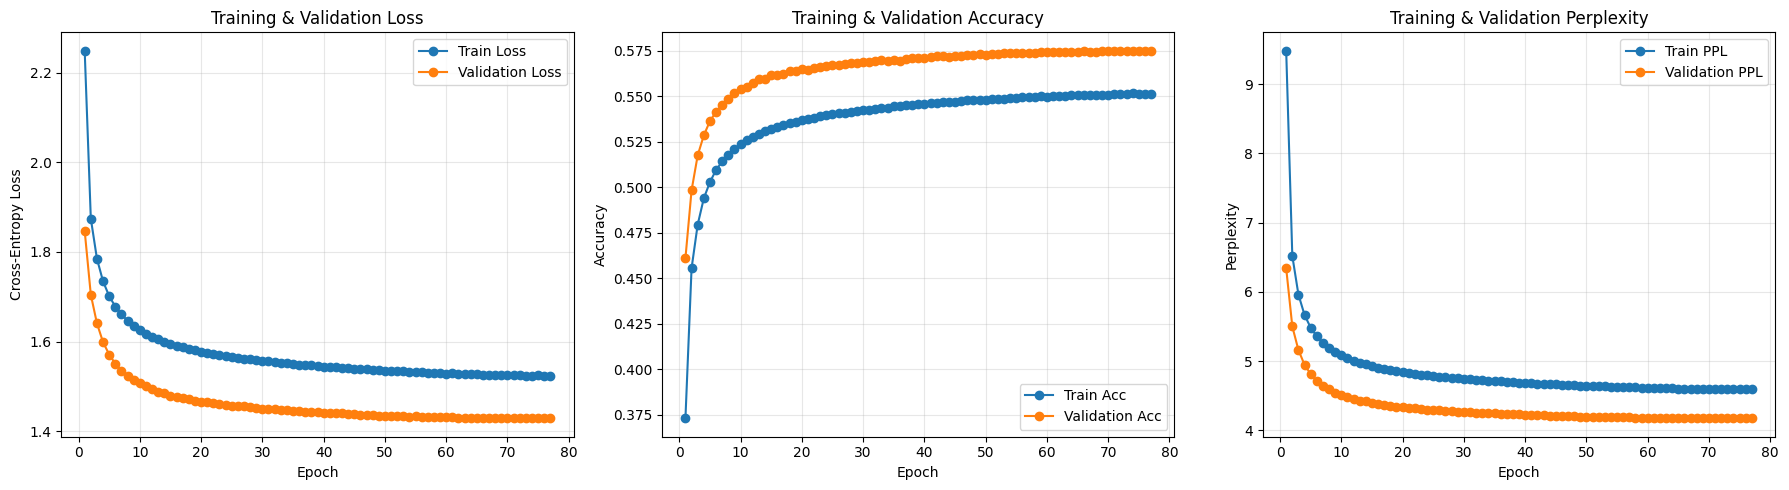

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(18, 5))

# Loss curve
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curve
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Acc', marker='o')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Perplexity curve
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_perplexities, label='Train PPL', marker='o')
plt.plot(epochs_range, val_perplexities, label='Validation PPL', marker='o')
plt.title('Training & Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnnlm_curves.png', dpi=150)  # useful if pulling this into a paper/report later
plt.show()

In [13]:
######################################################################
#                    Text Generation Function
######################################################################

@torch.no_grad()
def generate_text(model, seed_text: str, char2idx: dict, idx2char: dict,
                  length: int = 300, temperature: float = 0.8, top_k: int = None,
                  device: torch.device = device):
    '''Generate text autoregressively from an RNN language model.

    seed_text   : starting string (can be ANY length -- the RNN builds up its
                  hidden state from the full seed, unlike the feedforward model
                  which needed exactly context_size characters)

    length      : how many new characters to generate

    temperature : >1.0 = more random/diverse, <1.0 = more conservative/greedy,
                  1.0 = sample directly from the model's distribution

    top_k       : if set, restrict sampling to the k most likely next
                  characters at each step (filters out low-probability noise)
    '''
    model.eval()

    # Unknown-character safety: fall back to a known char (e.g. space) if seed
    # contains anything outside the training vocabulary.
    unk_fallback = char2idx.get(' ', 0)
    ids = [char2idx.get(ch, unk_fallback) for ch in seed_text]

    # --- Step 1: Prime the RNN with the full seed text ---
    # Feed the entire seed through the RNN in one pass to build up the hidden state.
    # Unlike the feedforward model, we don't need a fixed-length window -- the RNN
    # accepts any length and its hidden state captures the full history.
    input_seq = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, len(ids))
    logits, hidden = model(input_seq)
    # logits: (1, len(ids), vocab_size)   hidden: (num_layers, 1, hidden_dim)

    # --- Step 2: Sample the first generated character from the last time step ---
    next_logits = logits[0, -1, :] / max(temperature, 1e-8)   # (vocab_size,)

    if top_k is not None:
        top_k = min(top_k, next_logits.size(-1))
        top_vals, top_idx = torch.topk(next_logits, top_k)
        filtered_logits = torch.full_like(next_logits, float('-inf'))
        filtered_logits.scatter_(0, top_idx, top_vals)
        next_logits = filtered_logits

    probs = F.softmax(next_logits, dim=-1)                    # (vocab_size,)
    next_id = torch.multinomial(probs, num_samples=1).item()

    generated_chars = list(seed_text) + [idx2char[next_id]]

    # --- Step 3: Autoregressive loop -- feed one character at a time ---
    # Key difference from feedforward: we carry the HIDDEN STATE forward,
    # NOT a sliding context window. The hidden state IS the memory.
    for _ in range(length - 1):
        input_char = torch.tensor([[next_id]], dtype=torch.long, device=device)  # (1, 1)
        logits, hidden = model(input_char, hidden)
        # logits: (1, 1, vocab_size)   hidden: (num_layers, 1, hidden_dim)

        next_logits = logits[0, -1, :] / max(temperature, 1e-8)

        if top_k is not None:
            top_k = min(top_k, next_logits.size(-1))
            top_vals, top_idx = torch.topk(next_logits, top_k)
            filtered_logits = torch.full_like(next_logits, float('-inf'))
            filtered_logits.scatter_(0, top_idx, top_vals)
            next_logits = filtered_logits

        probs = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
        generated_chars.append(idx2char[next_id])

    return ''.join(generated_chars)

In [14]:
######################################################################
#              Generate samples at different settings
######################################################################

torch.manual_seed(123)   # reproducible generation output for the report

seed = "the island was covered with"

print("=== Temperature 0.5 (conservative) ===")
print(generate_text(model, seed, char2idx, idx2char, length=300, temperature=0.5))

print("\n=== Temperature 0.8, top_k=10 (balanced) ===")
print(generate_text(model, seed, char2idx, idx2char, length=300, temperature=0.8, top_k=10))

print("\n=== Temperature 1.2 (more random) ===")
print(generate_text(model, seed, char2idx, idx2char, length=300, temperature=1.2))

=== Temperature 0.5 (conservative) ===
the island was covered with a such a sort. She laid the nome of the possessed, and the sailor of the whale, which see that I was not its of the man of which it was a trianing of considerable to the same man, and the ship in the soul, and a species of his house of the engineer.

“I should have formed the point of the stupped o

=== Temperature 0.8, top_k=10 (balanced) ===
the island was covered with the whole of whochess of the sailors of their shicted to the letter my curious and
forder to be supposed to prove what I reached by the morning was the
colonists was on the wrant all the sleeps which they will not be seen that which was to speak of his commander, I was
sure, have not a sun what
spr

=== Temperature 1.2 (more random) ===
the island was covered with an abansate. But ivagning and codpent at lasfeeth, Miss Boran niwerf we
say, that
the fifexeasable sparpfech, and what genay entorene.
 Tapbling fureathongsish upon the certainod exeince I hav